In [1]:

from FlashDroughts import KDEhistogram,DroughtDetection, FlashDrought
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import shapefile
from shapely.geometry import shape
import pandas as pd
from matplotlib.animation import FuncAnimation,  PillowWriter
import ast
from IPython.display import HTML 
from IPython.display import Image



Creating the dataframe:
- Upload CSV file 
- For Northeast centers of each county use: UpdatedCounties.csv


In [2]:
#Counties 3 just has first three to test
df = pd.read_csv('Counties3.csv')

Creates the FlashDrought Object with columns:
- Variable: PET Residuals, Precip, VWC
- Conditions:
    - Threshold: categorical change (2 category increase)
    - Two timescales: 2-week and 4-week intervals (1 week for VWC)
    - detection types: 2-week and 4-week onset detection

- pd.DataFrame
    - A DataFrame where each row corresponds to a location and contains:
        - County, latitude, longitude
        - Counts of flash droughts under each condition

Insert start date:
- For Northeast starts March 1, 2002

In [3]:
start_date = '2002-03-01'

In [4]:
# TAKES 1-2 HOURS to RUN
def clean_coord(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    val = re.sub(r'[–—−]', '-', val) 
    val = val.replace('°', '')       
    try:
        return float(val)
    except ValueError:
        return np.nan

df['lat'] = df['lat'].apply(clean_coord)
df['lon'] = df['lon'].apply(clean_coord)
df = df.drop(columns=['Unnamed: 4','Unnamed: 5','Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9','Unnamed: 10','Unnamed: 11','Unnamed: 12','Unnamed: 13'])
locations = df[['state', 'county', 'lat', 'lon']].to_dict(orient='records')
fd = FlashDrought(locations)
fd.combined_df(start_date)


,State,County,lat,lon,# Droughts PET (2 CAT/2wk)(2 wk intervals),# Droughts PET (2 CAT/2wk)(4 wk intervals),# Droughts PET (2 CAT/4wk)(2 wk intervals),# Droughts PET (2 CAT/4wk)(4 wk intervals),# Droughts VWC (2 CAT/2wk)(Tuesdays),# Droughts VWC (2 CAT/4wk)(Tuesdays),# Droughts Precip (2 CAT/2wk)(2 wk intervals),# Droughts Precip (2 CAT/2wk)(4 wk intervals),# Droughts Precip (2 CAT/4wk)(2 wk intervals),# Droughts Precip (2 CAT/4wk)(4 wk intervals)
0,CT,Fairfield,41.228103,-73.366757,10,18,9,18,10,9,12,19,14,19
1,CT,Hartford,41.806053,-72.732916,11,22,6,22,12,14,9,10,9,10
2,CT,Litchfield,41.791897,-73.235428,12,15,10,15,10,6,14,19,8,19


In [5]:
combined = _  
combined.to_csv('Output.csv')

Creating the distribution graphs for indivdual variables and conditions

Load the Output csv file:

In [6]:
df = combined

Clean the data:

In [7]:
# Strip spaces and lowercase for clean matching
df['County'] = df['County'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()

# Add combined key for matching
df['county_state'] = df['County'] + '_' + df['State']

statefp_to_abbr = {
    '09': 'ct', '23': 'me', '25': 'ma', '33': 'nh', '34': 'nj',
    '36': 'ny', '42': 'pa', '44': 'ri', '50': 'vt', '24': 'md',
    '54': 'wv', '10': 'de'
}

# Read shapefile
sf = shapefile.Reader("/Users/adriennekirk/Downloads/tl_2020_us_county/tl_2020_us_county.shp")
records = sf.shapeRecords()

Insert column name:

In [10]:
value_col = '# Droughts PET (2 CAT/2wk)(4 wk intervals)'

Optional: Change min and max of gradient legend

In [11]:
vmin = df[value_col].min()
vmax = df[value_col].max()

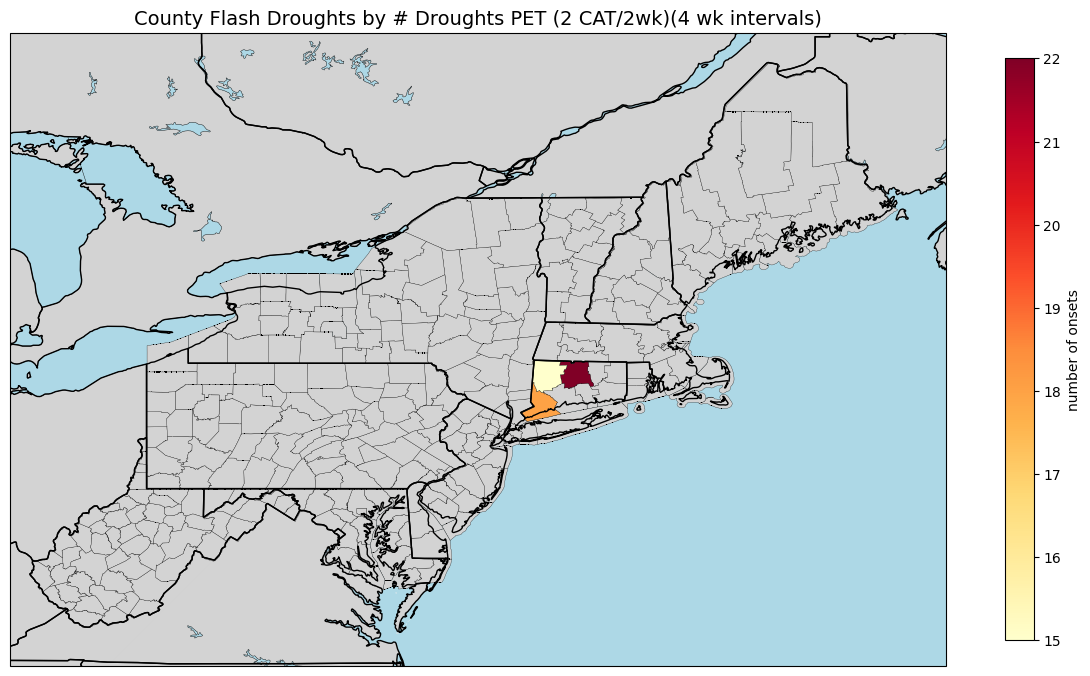

In [12]:
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('YlOrRd', 256)

fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-83, -66, 36.5, 48], crs=ccrs.PlateCarree())


for rec in records:
    attrs = rec.record.as_dict()
    county_name = attrs['NAME'].lower().strip()
    statefp = attrs['STATEFP']
    state_abbr = statefp_to_abbr.get(statefp, None)
    if not state_abbr:
        continue

    key = f"{county_name}_{state_abbr}"
    geom = shape(rec.shape.__geo_interface__)

    if key in df['county_state'].values:
        value = df.loc[df['county_state'] == key, value_col].values[0]
        color = cmap(norm(value))
    else:
        color = 'lightgrey'

    ax.add_geometries([geom], crs=ccrs.PlateCarree(),
                      facecolor=color, edgecolor='black', linewidth=0.2)


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label= 'number of onsets', shrink=0.6)


ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.LAKES, facecolor='lightblue', edgecolor='black', linewidth=0.3, zorder=1)
ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='none')

plt.title(f"County Flash Droughts by {value_col}", fontsize=14)
plt.tight_layout()
plt.show()